# 06 — Frenet Coordinates and Minimum-Time Racing

## Geometry first, then spatial dynamics, then a minimum-time speed planner

A raceline is not simply “the center of the road driven as fast as possible.”

The offline raceline problem is:

- choose a trajectory inside the track;
- obey the vehicle dynamics;
- obey tire-force limits;
- minimize the total lap time.

It is formulated most naturally in **Frenet coordinates**, where progress along the track is the
independent spatial variable.

This notebook develops that mathematics carefully and then solves a reduced but fully executable
subproblem:

$$
\boxed{
\text{minimum-time speed planning on a closed centerline}
}
$$

subject to:

- curvature-limited lateral acceleration;
- maximum speed;
- longitudinal acceleration limits;
- longitudinal braking limits.

The reduced planner is deliberately **not** presented as the full tire-force raceline optimizer.
The full problem is nonlinear and also optimizes the lateral offset and the vehicle dynamics.


## Scope

The notebook follows the standard spatial formulation of minimum-lap-time problems, in which arc
length along the track replaces time as the independent variable. It derives:

- the track centerline $\gamma(s)$ and its curvature $K(s)$;
- the Frenet variables $(s,e_y,e_\psi)$;
- the track constraint $|e_y|\le W(s)$;
- the spatial transformation

$$
\frac{dx}{ds}
=
\frac{\dot x}{\dot s};
$$

- the six-state spatial formulation

$$
x=
[v_x,v_y,r,e_\psi,t,e_y]^\top;
$$

- longitudinal progress

$$
\dot s
=
\frac{
v_x\cos e_\psi-v_y\sin e_\psi
}{
1-K(s)e_y
};
$$

- time as a state;
- minimum terminal time $t(s_f)$;
- nonlinear CFTOC with tire-force and track constraints.

The full raceline problem is a nonlinear program. It is usually solved by discretizing the spatial
dynamics on a grid in $s$ (for example with Pyomo) and calling a nonlinear solver such as IPOPT.

This notebook does not solve that full problem. It derives the underlying geometry and dynamics,
writes out the dynamic bicycle model of a 1:10-scale RC car (BARC parameters) that notebook 07
simulates, and implements a lightweight spatial speed planner, which needs only NumPy, along the
fixed centerline of a synthetic closed track.

For the full minimum-lap-time formulation, see G. Perantoni and D. J. N. Limebeer, “Optimal control
for a Formula One car with variable parameters,” *Vehicle System Dynamics*, 52(5), 2014. For racing
in Frenet coordinates with a dynamic bicycle model and Learning MPC, see U. Rosolia and F. Borrelli,
“Learning How to Autonomously Race a Car: A Predictive Control Approach,” *IEEE Transactions on
Control Systems Technology*, 28(6), 2020.

## Learning objectives

After completing this notebook, you should be able to:

1. define the Frenet tangent and normal frame along a centerline;
2. derive signed curvature from a planar curve;
3. derive the coordinate map

$$
p=\gamma(s)+e_y n(s);
$$

4. explain why the factor

$$
1-K(s)e_y
$$

appears in Frenet kinematics;
5. derive $\dot s$, $\dot e_y$, and $\dot e_\psi$;
6. convert time-domain dynamics to spatial dynamics;
7. explain why $\dot s>0$ is essential;
8. formulate minimum lap time by making time a state;
9. distinguish a full nonlinear raceline problem from a centerline speed-planning problem;
10. derive

$$
\frac{d(v^2)}{ds}=2a;
$$

11. derive the curvature speed limit

$$
v^2|K|\le\mu g;
$$

12. derive the exact segment-time formula under constant longitudinal acceleration;
13. derive the forward acceleration and backward braking envelopes;
14. explain why braking must begin **before** a tight corner;
15. compute a closed-lap minimum-time speed profile;
16. quantify how friction and braking authority affect lap time;
17. understand spatial-grid convergence;
18. diagnose why separate longitudinal/lateral limits can be optimistic compared with a friction
circle;
19. connect the offline raceline concept to later MPC and Learning MPC.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.racing import (
    build_demo_track,
    frenet_rates,
    bicycle_lateral_forces,
    bicycle_spatial_rhs,
    lateral_speed_squared_cap,
    segment_time_from_speed_squared,
    periodic_minimum_time_speed_profile,
    friction_circle_utilization,
)

np.set_printoptions(precision=6, suppress=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — What is the racing optimal-control problem?](#part-1)** — I.1 Raceline versus tracking · I.2 Why Cartesian coordinates are inconvenient on a track
- **[Part II — Differential geometry of the centerline](#part-2)** — II.1 Arc-length parameterization · II.2 Normal vector · II.3 Signed curvature
- **[Part III — Build a synthetic periodic track](#part-3)** — III.1 Why use a synthetic track here? · III.2 Radius of curvature
- **[Part IV — Frenet position map](#part-4)** — IV.1 Position represented by $(s,e_y)$ · IV.2 Differentiate the Frenet position map · IV.3 Frenet-coordinate singularity
- **[Part V — Vehicle velocity in the Frenet frame](#part-5)** — V.1 Heading error · V.2 Body-frame velocity components · V.3 Derive longitudinal progress $\dot s$ · V.4 Derive lateral motion · V.5 Derive heading-error dynamics
- **[Part VI — From time dynamics to spatial dynamics](#part-6)** — VI.1 Chain-rule transformation · VI.2 Why $\dot s>0$ matters · VI.3 Spatial Frenet kinematics
- **[Part VII — Time as a state and the minimum-time objective](#part-7)** — VII.1 Why introduce time as a state? · VII.2 The six-state spatial vector
- **[Part VIII — The dynamic bicycle model](#part-8)** — VIII.1 Tire slip angles and lateral forces · VIII.2 Vehicle time dynamics · VIII.3 The full raceline CFTOC
- **[Part IX — Why this notebook solves a reduced problem](#part-9)** — IX.1 Centerline speed-planning assumptions
- **[Part X — Spatial longitudinal dynamics](#part-10)** — X.1 Begin in time · X.2 Introduce squared speed · X.3 Spatial discretization
- **[Part XI — Curvature-limited speed](#part-11)** — XI.1 Lateral acceleration · XI.2 Speed-squared cap
- **[Part XII — Minimum-time objective in the spatial grid](#part-12)** — XII.1 Time across one segment · XII.2 Exact segment-time formula · XII.3 Total lap time
- **[Part XIII — Acceleration and braking envelopes](#part-13)** — XIII.1 Forward acceleration constraint · XIII.2 Backward braking constraint · XIII.3 Why braking information moves backward
- **[Part XIV — Why the local curvature cap alone is infeasible](#part-14)** — XIV.1 Naive profile
- **[Part XV — Closed-lap forward/backward planner](#part-15)** — XV.1 Algorithm · XV.2 Why the greatest feasible profile is minimum-time · XV.3 Active constraints
- **[Part XVI — Braking preview around the tightest corner](#part-16)** — XVI.1 Find the tightest corner
- **[Part XVII — Cumulative lap time](#part-17)** — XVII.1 Time as a spatial state in the reduced model
- **[Part XVIII — Friction sensitivity](#part-18)** — XVIII.1 Friction coefficient changes the curvature cap
- **[Part XIX — Acceleration versus braking authority](#part-19)** — XIX.1 Two different physical roles
- **[Part XX — Spatial-grid convergence](#part-20)** — XX.1 Why discretization density matters
- **[Part XXI — An important limitation: tire-force coupling](#part-21)** — XXI.1 Separate limits can be optimistic
- **[Part XXII — Why a full raceline can be faster than centerline speed planning](#part-22)** — XXII.1 The centerline is not generally the minimum-time path · XXII.2 Why the full problem is nonlinear
- **[Part XXIII — From offline raceline to MPC and LMPC](#part-23)** — XXIII.1 The standard pipeline
- **[Part XXIV — Conventions worth keeping straight](#part-24)** — XXIV.1 Mathematical normal versus code normal · XXIV.2 Input ordering · XXIV.3 Offline raceline versus online LMPC racing
- **[Part XXV — Common pitfalls](#part-25)** — XXV.1 Pitfall: Frenet coordinates mean the vehicle is constrained to the centerline · XXV.2 Pitfall: curvature alone determines the optimal speed · XXV.3 Pitfall: brake at the point where the speed cap becomes small · XXV.4 Pitfall: $2\Delta s/(v_i+v_{i+1})$ is just an arbitrary trapezoidal rule · XXV.5 Pitfall: $1-Ke_y$ is just a numerical denominator · XXV.6 Pitfall: independent longitudinal and lateral acceleration limits are the same as tire-force constraints · XXV.7 Pitfall: the reduced speed planner is the full raceline optimizer
- **[Part XXVI — Check your understanding](#part-26)**
- **[Part XXVII — Exercises](#part-27)**
- **[Part XXVIII — References](#part-28)**


<a id="part-1"></a>
# Part I — What is the racing optimal-control problem?

## I.1 Raceline versus tracking

Racing control is usually split into two tasks.

### Offline raceline computation

Find a minimum-time trajectory satisfying vehicle, tire, and track constraints.

### Online tracking

Once the raceline is known, use MPC or Learning MPC to track it.

Symbolically,

$$
\boxed{
\text{offline time-optimal trajectory}
\longrightarrow
\text{online tracking controller}
}
$$

Notebook 06 focuses on the geometry and the offline minimum-time viewpoint.

Later notebooks use the same Frenet concepts inside data-driven prediction and Learning MPC.


## I.2 Why Cartesian coordinates are inconvenient on a track

Suppose the track is described in Cartesian coordinates

$$
p=
\begin{bmatrix}
X\\Y
\end{bmatrix}.
$$

The constraint “remain inside the road” then requires geometric relations between the vehicle
position and two curved boundaries.

If instead the road is parameterized by arc length $s$, the same track constraint becomes

$$
\boxed{
-W(s)\le e_y(s)\le W(s).
}
$$

This is one of the main reasons Frenet coordinates are so useful for racing and path-following
optimal control.


<a id="part-2"></a>
# Part II — Differential geometry of the centerline

## II.1 Arc-length parameterization

Let

$$
\gamma(s)
=
\begin{bmatrix}
X_c(s)\\Y_c(s)
\end{bmatrix}
$$

denote the track centerline.

If $s$ is exact arc length, then

$$
\left\|
\gamma'(s)
\right\|_2=1.
$$

The unit tangent is

$$
\boxed{
t(s)=\gamma'(s).
}
$$

More generally, if a spline parameter is only approximately arc length,

$$
t(s)
=
\frac{\gamma'(s)}
{\|\gamma'(s)\|_2}.
$$


## II.2 Normal vector

For

$$
t=
\begin{bmatrix}
t_x\\t_y
\end{bmatrix},
$$

choose the left normal

$$
\boxed{
n=
\begin{bmatrix}
-t_y\\t_x
\end{bmatrix}.
}
$$

Then

$$
t^\top n=0,
\qquad
\|n\|_2=1.
$$

Some implementations use the opposite (right) normal

$$
[t_y,-t_x]^\top
$$

and simultaneously subtract $e_y$ times that normal.

Those two sign changes cancel, so the resulting Cartesian mapping is equivalent: in both conventions,
$e_y>0$ lies to the left of the direction of travel. In `racing.py`, `Track.normal()` returns the
left normal $n$.


## II.3 Signed curvature

For a planar curve parameterized by a generic parameter,

$$
\gamma(s)
=
\begin{bmatrix}
X(s)\\Y(s)
\end{bmatrix},
$$

the signed curvature is

$$
\boxed{
K(s)
=
\frac{
X'(s)Y''(s)-Y'(s)X''(s)
}{
\left(X'(s)^2+Y'(s)^2\right)^{3/2}
}.
}
$$

If $s$ is exact arc length, the Frenet–Serret relations are

$$
\boxed{
t'(s)=K(s)n(s)
}
$$

and

$$
\boxed{
n'(s)=-K(s)t(s).
}
$$

The sign of $K$ indicates the turning direction under the chosen orientation.


<a id="part-3"></a>
# Part III — Build a synthetic periodic track

## III.1 Why use a synthetic track here?

Real track maps are usually given as measured centerline points and represented by a periodic cubic
spline, from which tangent and curvature are computed.

This notebook uses a smooth closed curve with a closed-form expression instead,

$$
X_c(\theta)=45\cos\theta+5\cos 2\theta,
\qquad
Y_c(\theta)=30\sin\theta+6\sin 3\theta,
\qquad
\theta\in[0,2\pi),
$$

driven counter-clockwise from $(50,0)$. (The curve parameter is called $\theta$ because $t$ already
denotes both time and the unit tangent.) Heading and curvature are evaluated from the exact
derivatives of the curve, the arc length is integrated numerically on a dense parameter grid, and
the centerline is then sampled uniformly in arc length. The track has two tight corners, two
sweeping bends, and two slight reverse kinks on the long sides; its half-width is $W=3$ m.

The purpose is to study:

- arc-length parameterization of a closed curve;
- tangent and normal vectors;
- curvature;
- track boundaries;
- spatial speed planning.

In [2]:
track = build_demo_track(
    n=240,
    half_width=3.0,
)

print(f"track length: {track.length:.3f} m")
print(
    "curvature range:",
    f"[{track.curvature.min():.5f}, "
    f"{track.curvature.max():.5f}] 1/m",
)
print(
    "maximum |curvature|:",
    np.max(np.abs(track.curvature)),
)


track length: 252.333 m
curvature range: [-0.01255, 0.12943] 1/m
maximum |curvature|: 0.1294303413979461


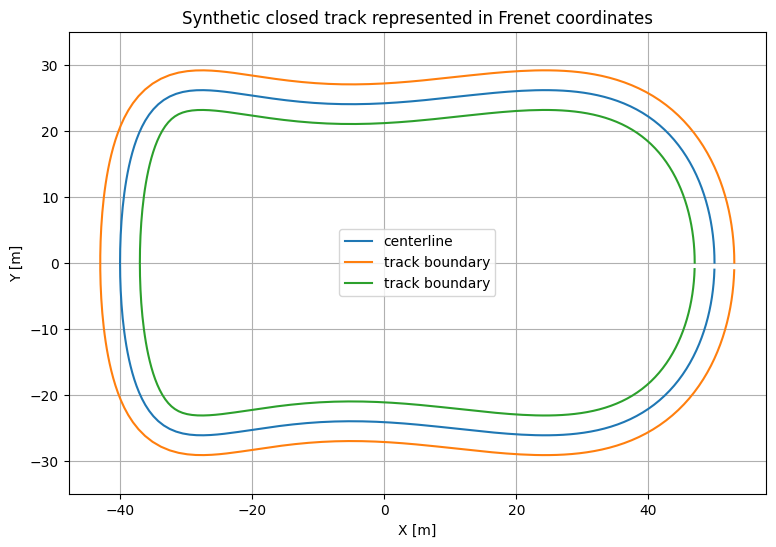

In [3]:
inner = track.to_global(-track.half_width)
outer = track.to_global(track.half_width)

plt.figure(figsize=(9, 6))
plt.plot(track.xy[:, 0], track.xy[:, 1], label="centerline")
plt.plot(inner[:, 0], inner[:, 1], label="track boundary")
plt.plot(outer[:, 0], outer[:, 1], label="track boundary")
plt.axis("equal")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Synthetic closed track represented in Frenet coordinates")
plt.legend()
plt.show()


### How to read the track figure

The center curve is

$$
\gamma(s).
$$

The two outer curves are obtained from

$$
\gamma(s)\pm W(s)n(s).
$$

A vehicle position represented by $(s,e_y)$ lies on the normal line through $\gamma(s)$.

The road constraint is therefore simply

$$
|e_y|\le W.
$$


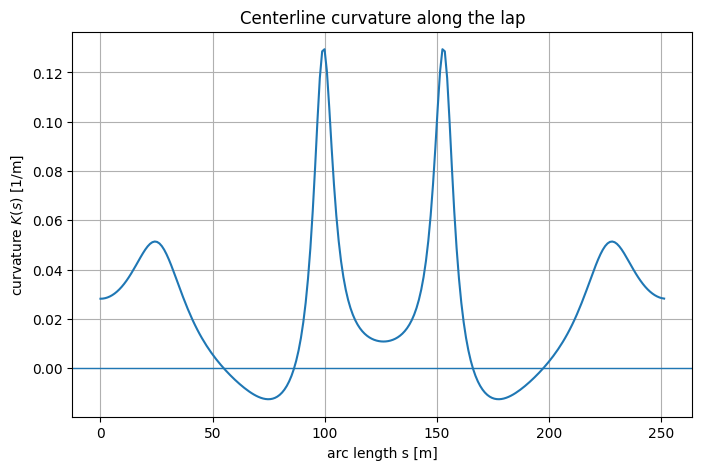

In [4]:
plt.figure()
plt.plot(track.s, track.curvature)
plt.axhline(0.0, linewidth=1)
plt.xlabel("arc length s [m]")
plt.ylabel(r"curvature $K(s)$ [1/m]")
plt.title("Centerline curvature along the lap")
plt.show()


## III.2 Radius of curvature

Where $K(s)\neq0$, the local signed radius is

$$
R(s)=\frac{1}{K(s)}.
$$

For speed limits, the magnitude matters:

$$
|R(s)|=\frac{1}{|K(s)|}.
$$

Large $|K|$ means a tight corner.
Small $|K|$ means a nearly straight segment.


In [5]:
idx_tight = int(np.argmax(np.abs(track.curvature)))

print("tightest sampled point:")
print(f"  s = {track.s[idx_tight]:.3f} m")
print(f"  K = {track.curvature[idx_tight]:.6f} 1/m")
print(
    "  radius magnitude =",
    1.0 / abs(track.curvature[idx_tight]),
    "m",
)


tightest sampled point:
  s = 99.882 m
  K = 0.129430 1/m
  radius magnitude = 7.726163658375924 m


<a id="part-4"></a>
# Part IV — Frenet position map

## IV.1 Position represented by $(s,e_y)$

With the left normal of Part II, a point at arc length $s$ and lateral offset $e_y$ is

$$
\boxed{
p
=
\gamma(s)
+
e_y n(s).
}
$$

The track centerline corresponds to

$$
e_y=0.
$$

The two road edges correspond to

$$
e_y=-W(s),
\qquad
e_y=+W(s).
$$


## IV.2 Differentiate the Frenet position map

Start from

$$
p(t)
=
\gamma(s(t))
+
e_y(t)n(s(t)).
$$

Differentiate with respect to time:

$$
\dot p
=
\gamma'(s)\dot s
+
\dot e_y n
+
e_y n'(s)\dot s.
$$

Using

$$
\gamma'(s)=t,
\qquad
n'(s)=-K(s)t,
$$

gives

$$
\dot p
=
t\dot s
+
n\dot e_y
-
K e_y t\dot s.
$$

Hence

$$
\boxed{
\dot p
=
(1-Ke_y)\dot s\,t
+
\dot e_y\,n.
}
$$

This equation explains the important geometric factor

$$
\boxed{
1-Ke_y.
}
$$


## IV.3 Frenet-coordinate singularity

The map becomes locally singular when

$$
1-K(s)e_y=0.
$$

Geometrically, this occurs when the lateral offset reaches the local center of curvature.

A practical Frenet corridor should stay away from that condition.

A simple conservative check is

$$
\boxed{
1-|K(s)|W(s)>0
}
$$

for every point on the track.


minimum conservative Frenet-coordinate margin: 0.6117089758061617


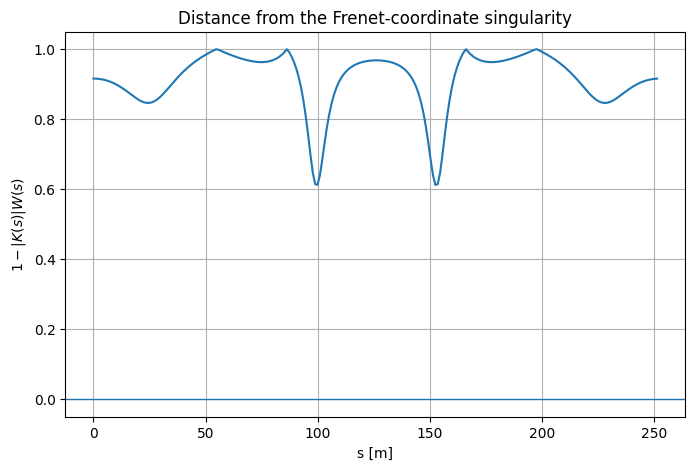

In [6]:
frenet_margin = 1.0 - np.abs(track.curvature) * track.half_width

print(
    "minimum conservative Frenet-coordinate margin:",
    np.min(frenet_margin),
)

plt.figure()
plt.plot(track.s, frenet_margin)
plt.axhline(0.0, linewidth=1)
plt.xlabel("s [m]")
plt.ylabel(r"$1-|K(s)|W(s)$")
plt.title("Distance from the Frenet-coordinate singularity")
plt.show()


For this synthetic track, the minimum margin is positive: the complete road corridor stays safely
on the regular side of the Frenet map.

That is a geometry check—not a dynamic safety guarantee.


<a id="part-5"></a>
# Part V — Vehicle velocity in the Frenet frame

## V.1 Heading error

Let

- $\psi$ be the vehicle yaw angle;
- $\psi_c(s)$ be the centerline tangent angle.

Define

$$
\boxed{
e_\psi
=
\psi-\psi_c(s).
}
$$

Thus $e_\psi=0$ means the vehicle is aligned with the local track tangent.


## V.2 Body-frame velocity components

Let

$$
v_x
$$

be the longitudinal vehicle velocity and

$$
v_y
$$

the lateral vehicle velocity in the vehicle body frame.

Relative to the track tangent/normal frame, the velocity components are

$$
\boxed{
v_t
=
v_x\cos e_\psi
-
v_y\sin e_\psi
}
$$

and

$$
\boxed{
v_n
=
v_x\sin e_\psi
+
v_y\cos e_\psi.
}
$$

The first is progress along the tangent direction.
The second is motion across the road.


## V.3 Derive longitudinal progress $\dot s$

From the differentiated Frenet position map,

$$
\dot p
=
(1-Ke_y)\dot s\,t+\dot e_y\,n.
$$

Equate the tangent component with $v_t$:

$$
(1-Ke_y)\dot s
=
v_x\cos e_\psi-v_y\sin e_\psi.
$$

Therefore

$$
\boxed{
\dot s
=
\frac{
v_x\cos e_\psi-v_y\sin e_\psi
}{
1-K(s)e_y
}.
}
$$

This progress relation is the central equation of Frenet-frame racing models: it converts the
body-frame velocity into progress along the track.


## V.4 Derive lateral motion

Equating the normal component gives

$$
\boxed{
\dot e_y
=
v_x\sin e_\psi
+
v_y\cos e_\psi.
}
$$

If

$$
e_\psi=0
\quad\text{and}\quad
v_y=0,
$$

then

$$
\dot e_y=0,
$$

as expected for perfect centerline alignment.


## V.5 Derive heading-error dynamics

The centerline tangent rotates with curvature:

$$
\frac{d\psi_c}{ds}=K(s).
$$

Hence

$$
\dot\psi_c
=
K(s)\dot s.
$$

If the vehicle yaw rate is $r=\dot\psi$, then

$$
\boxed{
\dot e_\psi
=
r-K(s)\dot s.
}
$$


In [7]:
rates = frenet_rates(
    vx=12.0,
    vy=0.4,
    yaw_rate=0.15,
    epsi=0.05,
    kappa=0.02,
    ey=0.5,
)

for key, value in rates.items():
    print(f"{key:22s}: {value:.8f}")


sdot                  : 12.08587016
eydot                 : 0.99925014
epsidot               : -0.09171740
dt_ds                 : 0.08274125
dey_ds                : 0.08267920
depsi_ds              : -0.00758881
denominator           : 0.99000000
tangential_velocity   : 11.96501146


<a id="part-6"></a>
# Part VI — From time dynamics to spatial dynamics

## VI.1 Chain-rule transformation

Suppose a time-domain state component obeys

$$
\dot\xi=f_\xi(x,u).
$$

If

$$
\dot s>0,
$$

then $s$ can be used as the independent variable:

$$
\boxed{
\frac{d\xi}{ds}
=
\frac{\dot\xi}{\dot s}.
}
$$

This is the fundamental transformation behind spatial (arc-length-based) raceline formulations.


## VI.2 Why $\dot s>0$ matters

If

$$
\dot s=0,
$$

then

$$
\frac{d\xi}{ds}
=
\frac{\dot\xi}{\dot s}
$$

is undefined.

If $\dot s<0$, the vehicle is moving backward relative to the chosen track orientation, which
breaks the ordinary forward-progress racing interpretation.

Spatial formulations therefore require longitudinal progress to remain positive along the whole
lap.


## VI.3 Spatial Frenet kinematics

Divide the time-domain expressions by $\dot s$.

For lateral deviation,

$$
\boxed{
\frac{de_y}{ds}
=
\frac{
(1-Ke_y)
\left(
v_x\sin e_\psi+v_y\cos e_\psi
\right)
}{
v_x\cos e_\psi-v_y\sin e_\psi
}.
}
$$

For heading error,

$$
\boxed{
\frac{de_\psi}{ds}
=
\frac{r}{\dot s}
-
K(s).
}
$$

For elapsed time,

$$
\boxed{
\frac{dt}{ds}
=
\frac{1}{\dot s}
=
\frac{
1-K(s)e_y
}{
v_x\cos e_\psi-v_y\sin e_\psi
}.
}
$$


<a id="part-7"></a>
# Part VII — Time as a state and the minimum-time objective

## VII.1 Why introduce time as a state?

In the spatial formulation, $s$ is no longer a state that evolves in time.
It is the independent variable.

To recover lap time, introduce

$$
t=t(s)
$$

with

$$
t'(s)=\frac{dt}{ds}.
$$

Then total lap time is simply

$$
\boxed{
T_{\mathrm{lap}}
=
t(s_f)-t(0).
}
$$

If $t(0)=0$,

$$
\boxed{
T_{\mathrm{lap}}=t(s_f).
}
$$


## VII.2 The six-state spatial vector

The full spatial raceline problem uses

$$
\boxed{
x(s)
=
\begin{bmatrix}
v_x&
v_y&
r&
e_\psi&
t&
e_y
\end{bmatrix}^{\!\top}.
}
$$

The semantic inputs are

$$
\boxed{
a_x,\qquad \delta
}
$$

for longitudinal acceleration and steering angle.

A detail worth keeping explicit: the order of the two inputs is only a convention.

- raceline formulations often write the input vector as $[a_x,\delta]^\top$;
- the racing code in this repository (`racing.py`, used again in notebook 07) stores
  $u=[\delta,a]^\top$: steering first and acceleration second.

This notebook therefore uses the **names** $a_x$ and $\delta$ instead of relying on an ambiguous
integer ordering.


<a id="part-8"></a>
# Part VIII — The dynamic bicycle model

## VIII.1 Tire slip angles and lateral forces

Notebook 07 simulates a dynamic bicycle model of a 1:10-scale RC car with the parameters of the BARC
platform: mass $m=1.98\ \mathrm{kg}$, distances $l_f=l_r=0.125\ \mathrm{m}$ from the center of
gravity to the front and rear axles, and yaw inertia $I_z=0.024\ \mathrm{kg\,m^2}$. The model is
implemented in `racing.py`.

Its front and rear slip-angle expressions are

$$
\boxed{
\alpha_f
=
\delta
-
\operatorname{atan2}
\left(
v_y+l_fr,
v_x
\right)
}
$$

and

$$
\boxed{
\alpha_r
=
-
\operatorname{atan2}
\left(
v_y-l_rr,
v_x
\right).
}
$$

Each axle's lateral force then follows a smooth saturating law of the form

$$
F_y
=
D\sin
\left(
C\arctan(B\alpha)
\right).
$$

This is the simplified Pacejka “magic formula,” with stiffness factor $B$, shape factor $C$ and
peak force $D$. The BARC parameters are $B=1$, $C=1.25$ and $D=0.8\,mg/2$: each axle carries half
of the weight (because $l_f=l_r$) and can deliver a peak lateral force of $0.8$ times its normal
load.


## VIII.2 Vehicle time dynamics

With these forces, the body-frame velocities and the yaw rate evolve as

$$
\boxed{
\dot v_x
=
a_x
-
\frac{F_{y,f}}{m}\sin\delta
+
rv_y
}
$$

$$
\boxed{
\dot v_y
=
\frac{
F_{y,f}\cos\delta+F_{y,r}
}{m}
-
rv_x
}
$$

and

$$
\boxed{
\dot r
=
\frac{
l_fF_{y,f}\cos\delta-l_rF_{y,r}
}{
I_z
}.
}
$$

The spatial derivatives are then obtained from

$$
v_x'=\frac{\dot v_x}{\dot s},
\qquad
v_y'=\frac{\dot v_y}{\dot s},
\qquad
r'=\frac{\dot r}{\dot s}.
$$

`bicycle_spatial_rhs` evaluates these spatial derivatives, together with $de_\psi/ds$,
$dt/ds=1/\dot s$ and $de_y/ds$, for the state $[v_x,v_y,r,e_\psi,t,e_y]$. The two cells below
evaluate the tire forces and this right-hand side at an example state.

In [8]:
example_force = bicycle_lateral_forces(
    vx=10.0,
    vy=0.25,
    yaw_rate=0.2,
    delta=0.08,
)

for key, value in example_force.items():
    print(f"{key:10s}: {value:.8f}")


alpha_f   : 0.05250693
alpha_r   : -0.02249620
Fyf       : 0.50910915
Fyr       : -0.21841526


In [9]:
state_example = np.array([
    10.0,   # vx
    0.25,   # vy
    0.20,   # yaw rate r
    0.04,   # heading error epsi
    0.00,   # elapsed time
    0.30,   # lateral deviation ey
])

rhs_spatial = bicycle_spatial_rhs(
    state_example,
    ax=1.0,
    delta=0.08,
    kappa=0.03,
)

labels = [
    "dvx/ds",
    "dvy/ds",
    "dr/ds",
    "depsi/ds",
    "dt/ds",
    "dey/ds",
]

for label, value in zip(labels, rhs_spatial):
    print(f"{label:10s}: {value:.8f}")


dvx/ds    : 0.10220261
dvy/ds    : -0.18406337
dr/ds     : 0.37534374
depsi/ds  : -0.01014427
dt/ds     : 0.09927866
dey/ds    : 0.06450069


## VIII.3 The full raceline CFTOC

The full minimum-time raceline problem can be summarized as

$$
\boxed{
\min t(s_f)
}
$$

subject to:

- the spatial vehicle dynamics;
- tire-force constraints;
- track boundaries

$$
-W(s)\le e_y(s)\le W(s);
$$

- initial conditions;
- terminal/periodic conditions.

This is a nonlinear optimal-control problem.

It is usually solved by direct transcription: the spatial DAE is discretized on a grid in $s$
(for example with Pyomo) and the resulting NLP is solved with a nonlinear solver such as IPOPT.
Perantoni and Limebeer (2014) solve a problem of this type for a Formula One car.


<a id="part-9"></a>
# Part IX — Why this notebook solves a reduced problem

## IX.1 Centerline speed-planning assumptions

To get an executable problem that isolates the minimum-time spatial reasoning, assume:

$$
e_y=0,
\qquad
e_\psi=0,
\qquad
v_y=0,
$$

and denote

$$
v_x=v.
$$

Then

$$
\dot s=v.
$$

We optimize only the speed around the fixed centerline.

What disappears from the decision problem:

- lateral offset;
- steering;
- yaw dynamics;
- tire slip;
- combined tire-force allocation.

What remains:

- track curvature;
- lateral speed limit;
- acceleration/braking;
- total time.


<a id="part-10"></a>
# Part X — Spatial longitudinal dynamics

## X.1 Begin in time

The reduced longitudinal dynamics are

$$
\dot v=a,
$$

and

$$
\dot s=v.
$$

Therefore

$$
\frac{dv}{ds}
=
\frac{\dot v}{\dot s}
=
\frac{a}{v}.
$$

The division by $v$ is inconvenient.


## X.2 Introduce squared speed

Define

$$
\boxed{
z=v^2.
}
$$

Differentiate with respect to $s$:

$$
\frac{dz}{ds}
=
2v\frac{dv}{ds}.
$$

Substitute

$$
\frac{dv}{ds}=\frac{a}{v}
$$

to obtain

$$
\boxed{
\frac{dz}{ds}=2a.
}
$$

This is one of the key transformations in spatial speed planning:

> nonlinear speed dynamics in $v$ become affine dynamics in squared speed $z=v^2$.


## X.3 Spatial discretization

For segment length $\Delta s_i$ and piecewise-constant acceleration $a_i$,

$$
\boxed{
z_{i+1}
=
z_i
+
2\Delta s_i a_i.
}
$$

Hence

$$
\boxed{
a_i
=
\frac{
z_{i+1}-z_i
}{
2\Delta s_i
}.
}
$$

Acceleration constraints become linear difference inequalities in $z$.


<a id="part-11"></a>
# Part XI — Curvature-limited speed

## XI.1 Lateral acceleration

For motion along a path of curvature $K$,

$$
a_{\mathrm{lat}}
=
v^2K.
$$

In magnitude,

$$
|a_{\mathrm{lat}}|
=
v^2|K|.
$$

Impose the reduced friction condition

$$
|a_{\mathrm{lat}}|
\le
\mu g.
$$

Then

$$
\boxed{
v^2|K|
\le
\mu g.
}
$$


## XI.2 Speed-squared cap

Because

$$
z=v^2,
$$

the lateral limit becomes

$$
\boxed{
z(s)
\le
\frac{\mu g}{|K(s)|}
}
$$

when $K\neq0$.

With an independent top-speed limit,

$$
v\le v_{\max},
$$

we obtain

$$
\boxed{
z_{\max}(s)
=
\min
\left(
v_{\max}^2,
\frac{\mu g}{|K(s)|}
\right).
}
$$

On a straight segment with $K=0$, only the top-speed limit remains.


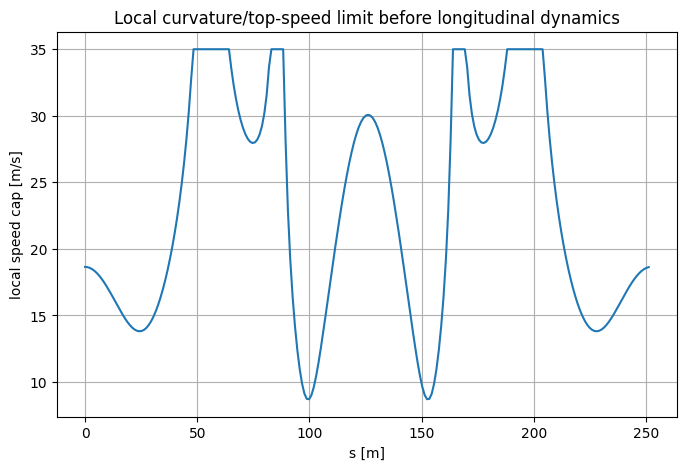

In [10]:
mu = 1.0
g = 9.81
vmax = 35.0

z_cap = lateral_speed_squared_cap(
    track.curvature,
    mu=mu,
    g=g,
    vmax=vmax,
)

v_cap = np.sqrt(z_cap)

plt.figure()
plt.plot(track.s, v_cap)
plt.xlabel("s [m]")
plt.ylabel("local speed cap [m/s]")
plt.title("Local curvature/top-speed limit before longitudinal dynamics")
plt.show()


The local cap answers only:

> How fast could the vehicle travel **at this location** if longitudinal acceleration history were
ignored?

It does not yet answer whether the vehicle can accelerate or brake quickly enough to move between
those local limits.


<a id="part-12"></a>
# Part XII — Minimum-time objective in the spatial grid

## XII.1 Time across one segment

Because

$$
dt=\frac{ds}{v},
$$

segment time is

$$
\Delta t_i
=
\int_{s_i}^{s_{i+1}}
\frac{ds}{v(s)}.
$$

If acceleration is constant over the segment, then $z=v^2$ is linear in $s$ and the integral can be
evaluated exactly.


## XII.2 Exact segment-time formula

Using

$$
z_{i+1}-z_i=2a_i\Delta s_i
$$

and

$$
v_i=\sqrt{z_i},
\qquad
v_{i+1}=\sqrt{z_{i+1}},
$$

constant acceleration gives

$$
v_{i+1}-v_i
=
a_i\Delta t_i.
$$

Also,

$$
v_{i+1}^2-v_i^2
=
(v_{i+1}-v_i)(v_{i+1}+v_i)
=
2a_i\Delta s_i.
$$

Therefore

$$
\boxed{
\Delta t_i
=
\frac{
2\Delta s_i
}{
v_i+v_{i+1}
}.
}
$$

This formula is exact for the piecewise-constant-acceleration segment model.


In [11]:
v0_demo = 10.0
v1_demo = 14.0
ds_demo = 30.0

z0_demo = v0_demo**2
z1_demo = v1_demo**2

a_demo = (z1_demo - z0_demo) / (2.0 * ds_demo)

dt_velocity = (v1_demo - v0_demo) / a_demo
dt_spatial = segment_time_from_speed_squared(
    z0_demo,
    z1_demo,
    ds_demo,
)

print("constant acceleration:", a_demo)
print("time from v1=v0+a dt:", dt_velocity)
print("time from spatial formula:", dt_spatial)


constant acceleration: 1.6
time from v1=v0+a dt: 2.5
time from spatial formula: 2.5


## XII.3 Total lap time

For a periodic spatial grid,

$$
\boxed{
T
=
\sum_i
\frac{
2\Delta s_i
}{
\sqrt{z_i}
+
\sqrt{z_{i+1}}
}.
}
$$

The index wraps around at the finish line.

For positive speeds, this objective decreases when a feasible speed-squared value increases.

That monotonicity is the reason the reduced optimum is the **largest dynamically feasible speed
profile** under the imposed caps.


<a id="part-13"></a>
# Part XIII — Acceleration and braking envelopes

## XIII.1 Forward acceleration constraint

From

$$
a_i
=
\frac{
z_{i+1}-z_i
}{
2\Delta s_i
}
$$

and

$$
a_i\le a_{\max},
$$

we obtain

$$
\boxed{
z_{i+1}
\le
z_i
+
2\Delta s_i a_{\max}.
}
$$

A forward pass propagates this upper bound around the track.


## XIII.2 Backward braking constraint

Let

$$
a_{\min}<0.
$$

From

$$
a_i\ge a_{\min},
$$

we get

$$
z_{i+1}-z_i
\ge
2\Delta s_i a_{\min}.
$$

Rearrange:

$$
\boxed{
z_i
\le
z_{i+1}
-
2\Delta s_i a_{\min}.
}
$$

Because $a_{\min}$ is negative, the right-hand side tells us the **largest speed we may have before
the next point if we still want enough braking authority to reach it**.

This constraint naturally propagates backward from a corner.


## XIII.3 Why braking information moves backward

Suppose a tight corner requires a small $z_{i+1}$.

The inequality

$$
z_i
\le
z_{i+1}
-
2\Delta s_i a_{\min}
$$

limits the speed one segment earlier.

That newly reduced $z_i$ then limits $z_{i-1}$.

Repeating the operation moves the corner's braking requirement upstream.

This is the mathematical statement behind the driving intuition:

$$
\boxed{
\text{brake before the corner, not after entering it.}
}
$$


<a id="part-14"></a>
# Part XIV — Why the local curvature cap alone is infeasible

## XIV.1 Naive profile

A tempting but wrong planner is

$$
z_i=z_{\max,i}.
$$

It respects the lateral speed limit at every point.

But it may jump too quickly between neighboring curvature caps, requiring impossible longitudinal
acceleration or braking.


In [12]:
z_naive = z_cap.copy()

a_naive = (
    np.roll(z_naive, -1) - z_naive
) / (
    2.0 * track.ds
)

violations_naive = np.sum(
    (a_naive > 3.0 + 1e-8)
    |
    (a_naive < -6.0 - 1e-8)
)

print("maximum naive acceleration:", np.max(a_naive))
print("minimum naive acceleration:", np.min(a_naive))
print(
    "segments violating longitudinal bounds:",
    violations_naive,
    "out of",
    len(a_naive),
)


maximum naive acceleration: 204.7706638105116
minimum naive acceleration: -204.7706638105116
segments violating longitudinal bounds: 142 out of 240


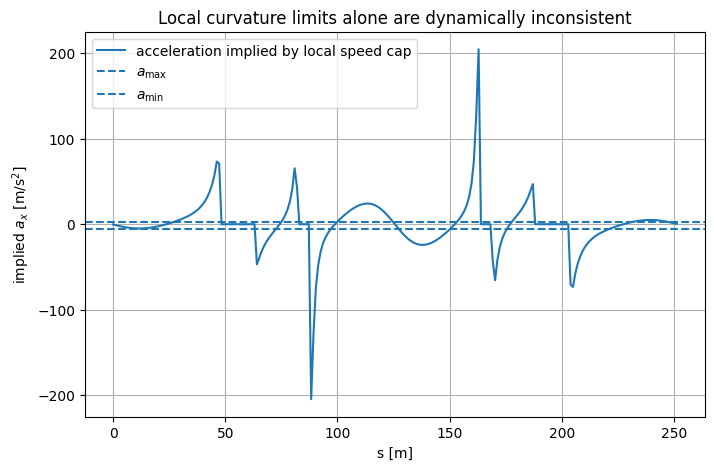

In [13]:
plt.figure()
plt.plot(track.s, a_naive, label="acceleration implied by local speed cap")
plt.axhline(3.0, linestyle="--", label=r"$a_{\max}$")
plt.axhline(-6.0, linestyle="--", label=r"$a_{\min}$")
plt.xlabel("s [m]")
plt.ylabel(r"implied $a_x$ [m/s$^2$]")
plt.title("Local curvature limits alone are dynamically inconsistent")
plt.legend()
plt.show()


This figure is intentionally extreme.

The curvature cap can change sharply from one spatial sample to the next.
Following it exactly would require unrealistically large acceleration changes.

The longitudinal dynamics must smooth that profile through forward and backward reachability.


<a id="part-15"></a>
# Part XV — Closed-lap forward/backward planner

## XV.1 Algorithm

Initialize with the local cap

$$
z_i^{(0)}=z_{\max,i}.
$$

Then repeatedly apply:

### Forward pass

$$
z_{i+1}
\leftarrow
\min
\left(
z_{i+1},
z_i+2\Delta s_i a_{\max}
\right).
$$

### Backward pass

$$
z_i
\leftarrow
\min
\left(
z_i,
z_{i+1}-2\Delta s_i a_{\min}
\right).
$$

Because the track is closed, indices are circular. Each iteration is one full forward sweep
followed by one full backward sweep around the loop, and the iterations stop when a sweep changes
nothing (to a tolerance of $10^{-9}$); `periodic_minimum_time_speed_profile` reports how many were
needed.

The algorithm only decreases values, so it converges to the greatest fixed point satisfying all
these upper-envelope constraints.


## XV.2 Why the greatest feasible profile is minimum-time

For every segment,

$$
\Delta t_i
=
\frac{
2\Delta s_i
}{
\sqrt{z_i}+\sqrt{z_{i+1}}
}.
$$

For positive $z_i$,

$$
\frac{\partial \Delta t_i}{\partial z_i}<0.
$$

Thus, if one feasible profile is componentwise larger than another, it cannot have a larger lap
time.

The envelope algorithm computes the largest profile compatible with:

- local speed caps;
- forward acceleration;
- backward braking.

Therefore it is the time-minimizing profile for this **reduced decoupled model**.


In [14]:
speed_solution = periodic_minimum_time_speed_profile(
    track,
    mu=1.0,
    vmax=35.0,
    amin=-6.0,
    amax=3.0,
)

print("planner success:", speed_solution["success"])
print(
    "forward/backward fixed-point iterations:",
    speed_solution["iterations"],
)
print(
    "lap time:",
    speed_solution["time"],
    "s",
)
print(
    "speed range:",
    speed_solution["v"].min(),
    "to",
    speed_solution["v"].max(),
    "m/s",
)
print(
    "acceleration range:",
    speed_solution["a"].min(),
    "to",
    speed_solution["a"].max(),
    "m/s^2",
)


planner success: True
forward/backward fixed-point iterations: 3
lap time: 17.09393800550383 s
speed range: 8.705955748145508 to 20.91357453979142 m/s
acceleration range: -6.0 to 3.0000000000000133 m/s^2


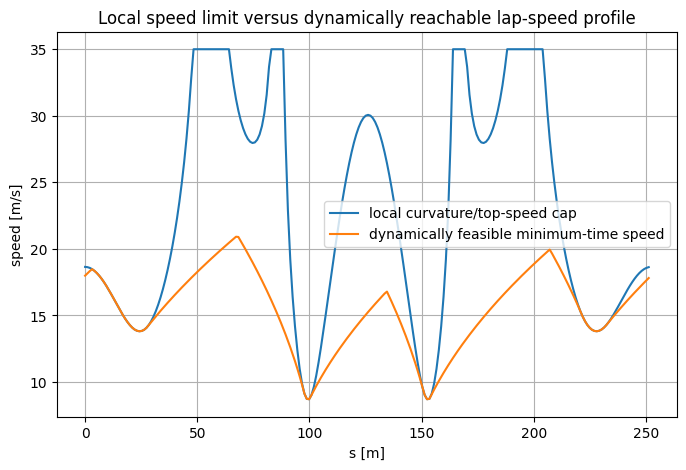

In [15]:
plt.figure()
plt.plot(track.s, np.sqrt(speed_solution["zmax"]),
         label="local curvature/top-speed cap")
plt.plot(track.s, speed_solution["v"],
         label="dynamically feasible minimum-time speed")
plt.xlabel("s [m]")
plt.ylabel("speed [m/s]")
plt.title("Local speed limit versus dynamically reachable lap-speed profile")
plt.legend()
plt.show()


### How to read the speed figure

The upper curve represents the speed that local curvature alone would permit.

The optimized curve may lie below it for two different reasons:

- **before a tight corner:** braking must start early;
- **after a tight corner:** acceleration is finite, so speed recovers gradually.

Where the two curves coincide, the local curvature/top-speed constraint is active.


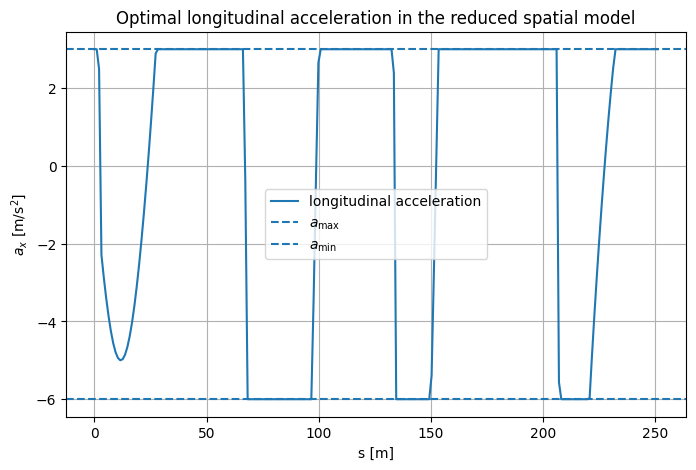

In [16]:
plt.figure()
plt.plot(track.s, speed_solution["a"], label="longitudinal acceleration")
plt.axhline(3.0, linestyle="--", label=r"$a_{\max}$")
plt.axhline(-6.0, linestyle="--", label=r"$a_{\min}$")
plt.xlabel("s [m]")
plt.ylabel(r"$a_x$ [m/s$^2$]")
plt.title("Optimal longitudinal acceleration in the reduced spatial model")
plt.legend()
plt.show()


## XV.3 Active constraints

The optimal profile frequently contains three kinds of segments:

1. maximum acceleration;
2. maximum braking;
3. local curvature/top-speed saturation.

This is a common structure in time-optimal path-parameterization problems.


In [17]:
a = speed_solution["a"]
z = speed_solution["z"]
cap = speed_solution["zmax"]

active_accel = np.isclose(a, 3.0, atol=1e-6)
active_brake = np.isclose(a, -6.0, atol=1e-6)
active_cap = np.isclose(z, cap, atol=1e-6)

print("segments at max acceleration:", int(active_accel.sum()))
print("segments at max braking:", int(active_brake.sum()))
print("points at local speed cap:", int(active_cap.sum()))


segments at max acceleration: 140
segments at max braking: 55
points at local speed cap: 45


<a id="part-16"></a>
# Part XVI — Braking preview around the tightest corner

## XVI.1 Find the tightest corner

Let

$$
i_c
=
\arg\max_i |K_i|.
$$

The local curvature cap becomes smallest near that point.

We inspect a spatial window around the corner and compare:

- curvature;
- local speed cap;
- feasible speed;
- longitudinal acceleration.


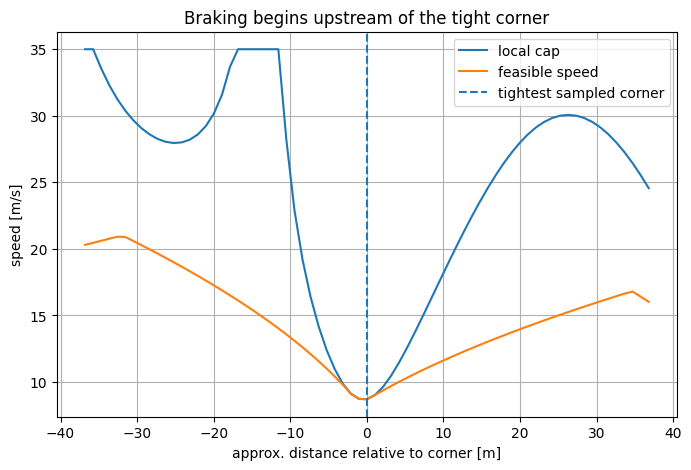

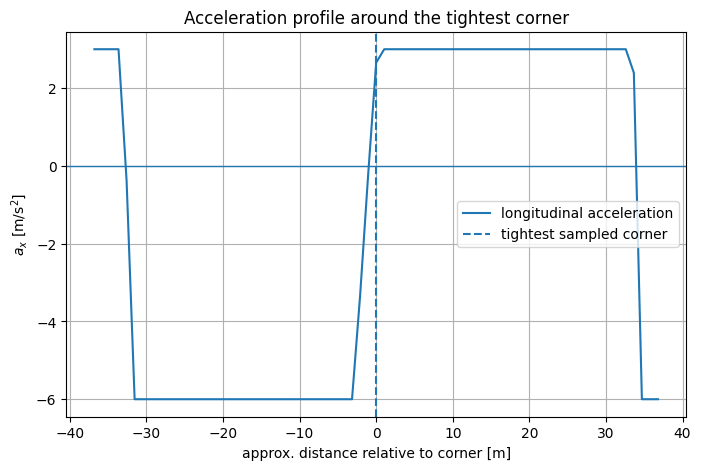

In [18]:
corner = int(np.argmax(np.abs(track.curvature)))

window = 35
indices = (
    np.arange(
        corner - window,
        corner + window + 1,
    )
    % len(track.s)
)

distance_to_corner = np.zeros(len(indices))

for j, idx in enumerate(indices):
    # Signed index-based local coordinate is enough for this explanatory plot
    distance_to_corner[j] = (j - window) * np.mean(track.ds)

plt.figure()
plt.plot(
    distance_to_corner,
    np.sqrt(speed_solution["zmax"])[indices],
    label="local cap",
)
plt.plot(
    distance_to_corner,
    speed_solution["v"][indices],
    label="feasible speed",
)
plt.axvline(0.0, linestyle="--", label="tightest sampled corner")
plt.xlabel("approx. distance relative to corner [m]")
plt.ylabel("speed [m/s]")
plt.title("Braking begins upstream of the tight corner")
plt.legend()
plt.show()

plt.figure()
plt.plot(
    distance_to_corner,
    speed_solution["a"][indices],
    label="longitudinal acceleration",
)
plt.axhline(0.0, linewidth=1)
plt.axvline(0.0, linestyle="--", label="tightest sampled corner")
plt.xlabel("approx. distance relative to corner [m]")
plt.ylabel(r"$a_x$ [m/s$^2$]")
plt.title("Acceleration profile around the tightest corner")
plt.legend()
plt.show()


The optimizer is not “reacting” to curvature only at the current position.

The backward envelope propagates future corner constraints into present speed decisions.

That is a deterministic form of preview.


<a id="part-17"></a>
# Part XVII — Cumulative lap time

## XVII.1 Time as a spatial state in the reduced model

The full spatial formulation of Part VII contains $t(s)$ explicitly as a state.

Our reduced planner can reconstruct the same quantity by accumulating segment times:

$$
t_{i+1}
=
t_i
+
\Delta t_i.
$$


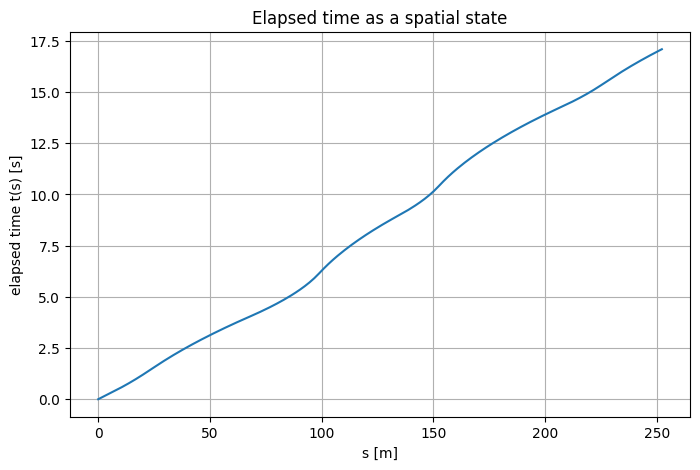

terminal elapsed time: 17.09393800550383 s


In [19]:
cumulative_time = np.r_[
    0.0,
    np.cumsum(speed_solution["segment_time"]),
]

s_closed = np.r_[
    track.s,
    track.length,
]

plt.figure()
plt.plot(s_closed, cumulative_time)
plt.xlabel("s [m]")
plt.ylabel("elapsed time t(s) [s]")
plt.title("Elapsed time as a spatial state")
plt.show()

print(
    "terminal elapsed time:",
    cumulative_time[-1],
    "s",
)


<a id="part-18"></a>
# Part XVIII — Friction sensitivity

## XVIII.1 Friction coefficient changes the curvature cap

The local bound is

$$
z
\le
\frac{\mu g}{|K|}.
$$

Therefore decreasing $\mu$ lowers the speed cap in curved regions.

It also changes how much speed must be removed before corners and how much can be carried through
them.


In [20]:
mu_values = [0.6, 0.8, 1.0, 1.2]
mu_solutions = {}

for mu_value in mu_values:
    mu_solutions[mu_value] = periodic_minimum_time_speed_profile(
        track,
        mu=mu_value,
        vmax=35.0,
        amin=-6.0,
        amax=3.0,
    )

    print(
        f"mu={mu_value:.1f}: "
        f"lap time={mu_solutions[mu_value]['time']:.4f} s"
    )


mu=0.6: lap time=20.1416 s
mu=0.8: lap time=18.3589 s
mu=1.0: lap time=17.0939 s
mu=1.2: lap time=16.1251 s


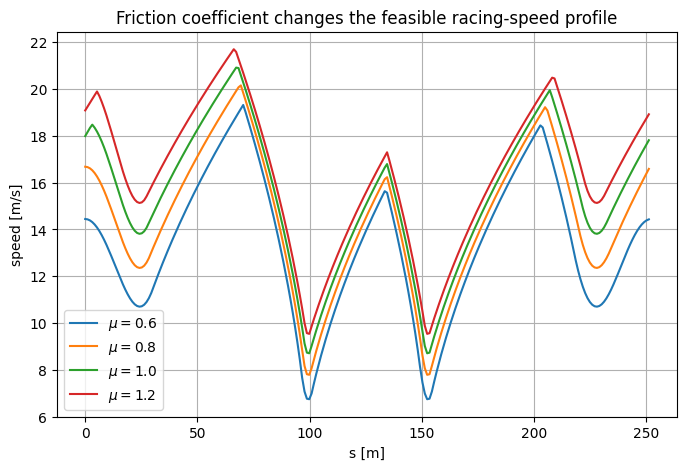

In [21]:
plt.figure()

for mu_value in mu_values:
    plt.plot(
        track.s,
        mu_solutions[mu_value]["v"],
        label=rf"$\mu={mu_value}$",
    )

plt.xlabel("s [m]")
plt.ylabel("speed [m/s]")
plt.title("Friction coefficient changes the feasible racing-speed profile")
plt.legend()
plt.show()


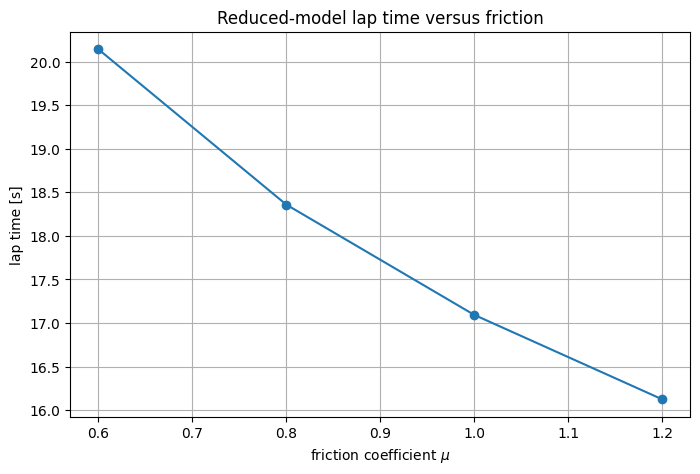

In [22]:
lap_times_mu = np.array([
    mu_solutions[mu_value]["time"]
    for mu_value in mu_values
])

plt.figure()
plt.plot(mu_values, lap_times_mu, "-o")
plt.xlabel(r"friction coefficient $\mu$")
plt.ylabel("lap time [s]")
plt.title("Reduced-model lap time versus friction")
plt.show()


Under this reduced model, higher friction cannot make the optimum worse because it relaxes the
local lateral speed constraints.

That monotonic conclusion follows from feasible-set inclusion.

A full tire model is more complicated, but the basic intuition remains: tire-force capability
strongly shapes minimum-time behavior.


<a id="part-19"></a>
# Part XIX — Acceleration versus braking authority

## XIX.1 Two different physical roles

Acceleration authority determines how rapidly speed can be regained after a slow corner.

Braking authority determines how late braking can begin before a slow corner.

They therefore affect different spatial regions of the optimal profile.


In [23]:
cases = [
    ("baseline", -6.0, 3.0),
    ("weaker braking", -3.5, 3.0),
    ("weaker acceleration", -6.0, 1.5),
]

case_solutions = {}

for name, amin, amax in cases:
    case_solutions[name] = periodic_minimum_time_speed_profile(
        track,
        mu=1.0,
        vmax=35.0,
        amin=amin,
        amax=amax,
    )

    print(
        f"{name:20s}: "
        f"lap time={case_solutions[name]['time']:.4f} s"
    )


baseline            : lap time=17.0939 s
weaker braking      : lap time=17.7318 s
weaker acceleration : lap time=18.7482 s


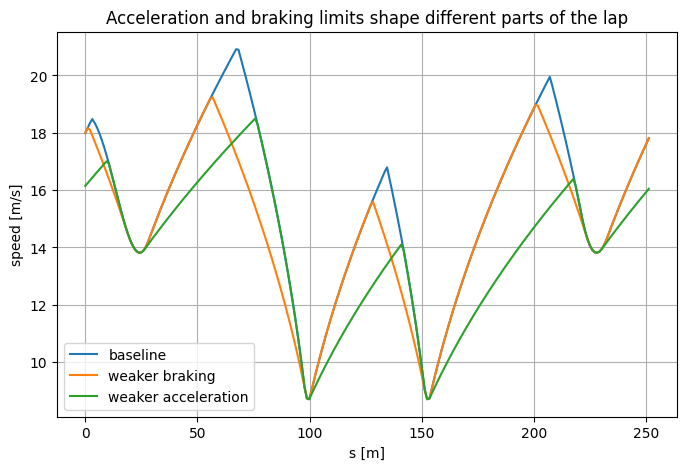

In [24]:
plt.figure()

for name, _, _ in cases:
    plt.plot(
        track.s,
        case_solutions[name]["v"],
        label=name,
    )

plt.xlabel("s [m]")
plt.ylabel("speed [m/s]")
plt.title("Acceleration and braking limits shape different parts of the lap")
plt.legend()
plt.show()


Weak braking pushes deceleration farther upstream.

Weak acceleration makes the post-corner recovery slower.

In a full vehicle model, these effects are additionally coupled to tire loading, steering, power,
and aerodynamic forces.


<a id="part-20"></a>
# Part XX — Spatial-grid convergence

## XX.1 Why discretization density matters

The continuous problem lives on

$$
s\in[0,s_f].
$$

A numerical optimizer or planner uses finitely many spatial nodes.

A grid that is too coarse can:

- miss curvature peaks;
- approximate braking zones poorly;
- bias lap time.

We therefore check whether the reduced solution stabilizes as the grid is refined.


In [25]:
grid_sizes = [60, 120, 240, 480]

grid_times = []

for n_grid in grid_sizes:
    track_grid = build_demo_track(
        n=n_grid,
        half_width=3.0,
    )

    sol_grid = periodic_minimum_time_speed_profile(
        track_grid,
        mu=1.0,
        vmax=35.0,
        amin=-6.0,
        amax=3.0,
    )

    grid_times.append(sol_grid["time"])

    print(
        f"N={n_grid:3d}: "
        f"lap time={sol_grid['time']:.8f} s"
    )


N= 60: lap time=16.93827668 s
N=120: lap time=17.07213924 s
N=240: lap time=17.09393801 s
N=480: lap time=17.10620213 s


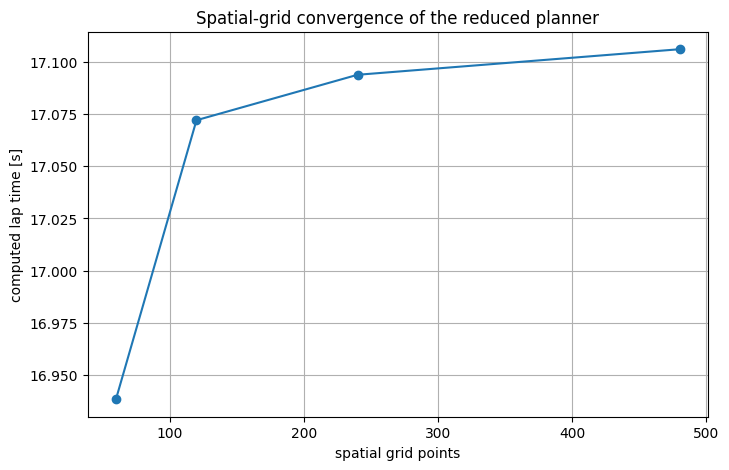

In [26]:
plt.figure()
plt.plot(grid_sizes, grid_times, "-o")
plt.xlabel("spatial grid points")
plt.ylabel("computed lap time [s]")
plt.title("Spatial-grid convergence of the reduced planner")
plt.show()


The values approach a limiting numerical result.

In this run the computed lap time increases with the number of grid points, and the increments
shrink. A coarse grid can step over the apex of a tight corner: it underestimates the peak
curvature, allows a higher minimum corner speed, and therefore returns an optimistic lap time.

The convergence is not required to be monotone in general, because both the curvature
representation and the piecewise spatial dynamics are changing with the grid.

<a id="part-21"></a>
# Part XXI — An important limitation: tire-force coupling

## XXI.1 Separate limits can be optimistic

Our reduced planner imposes:

$$
|a_x|\le a_{x,\max}
$$

and separately

$$
|a_y|
=
v^2|K|
\le
\mu g.
$$

But a physical tire has a limited **combined** force capability.

A simple approximation is the friction circle:

$$
\boxed{
a_x^2+a_y^2
\le
(\mu g)^2.
}
$$

With

$$
a_y=zK,
$$

this becomes

$$
\boxed{
a_x^2+(zK)^2
\le
(\mu g)^2.
}
$$

This coupling is an extension beyond the reduced planner and explains why a full tire-force
raceline problem is more difficult.


In [27]:
friction_usage = friction_circle_utilization(
    speed_solution["z"],
    speed_solution["a"],
    track.curvature,
    mu=1.0,
)

print(
    "maximum simple friction-circle utilization:",
    np.max(friction_usage),
)
print(
    "segments above 100% in this diagnostic:",
    int(np.sum(friction_usage > 1.0 + 1e-8)),
)


maximum simple friction-circle utilization: 1.1708172711379095
segments above 100% in this diagnostic: 66


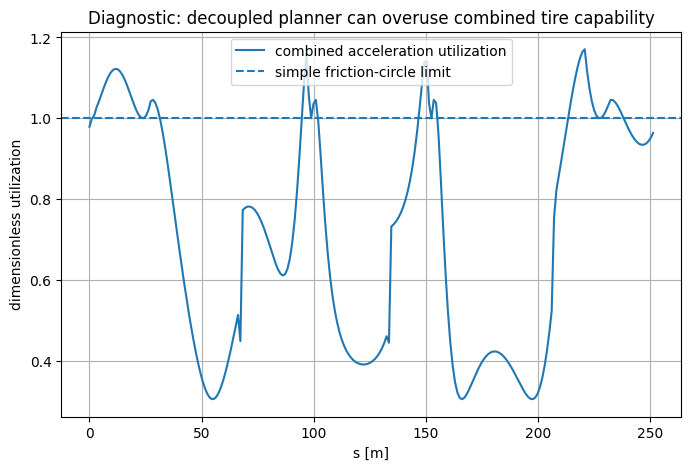

In [28]:
plt.figure()
plt.plot(
    track.s,
    friction_usage,
    label="combined acceleration utilization",
)
plt.axhline(
    1.0,
    linestyle="--",
    label="simple friction-circle limit",
)
plt.xlabel("s [m]")
plt.ylabel("dimensionless utilization")
plt.title("Diagnostic: decoupled planner can overuse combined tire capability")
plt.legend()
plt.show()


### How to interpret this diagnostic

A value

$$
\text{utilization}=1
$$

corresponds to the boundary of the simple combined-acceleration circle.

A value greater than one does **not** mean the notebook code is numerically wrong.

It means the **reduced model** allowed a combination of longitudinal and lateral acceleration that
the additional friction-circle model would forbid.

This is why full raceline formulations impose tire-force constraints rather than only an
independent curvature speed cap.


<a id="part-22"></a>
# Part XXII — Why a full raceline can be faster than centerline speed planning

## XXII.1 The centerline is not generally the minimum-time path

Our executable planner fixes

$$
e_y(s)=0.
$$

The full raceline problem optimizes

$$
e_y(s)
$$

inside

$$
-W(s)\le e_y(s)\le W(s).
$$

A racing trajectory can use the available width to:

- approach the outside of a corner;
- cut toward the inside;
- exit toward the outside.

This can reduce the effective curvature experienced by the vehicle and permit a higher speed
through the turn.

Therefore

$$
\boxed{
\text{centerline minimum-time speed planning}
\neq
\text{full minimum-time raceline optimization}.
}
$$


## XXII.2 Why the full problem is nonlinear

The complete problem contains several nonlinearities:

- trigonometric Frenet geometry;
- denominator

$$
1-Ke_y;
$$

- nonlinear tire-force laws;
- steering-dependent force projections;
- the minimum-time term

$$
t'=\frac{1}{\dot s};
$$

- possibly combined tire-force constraints.

That is why the full raceline is computed by solving a nonlinear program rather than a QP.


<a id="part-23"></a>
# Part XXIII — From offline raceline to MPC and LMPC

## XXIII.1 The standard pipeline

Once the raceline is computed offline, one can store reference profiles such as

$$
e_y^\star(s),
\quad
v_x^\star(s),
\quad
e_\psi^\star(s),
\quad
u^\star(s).
$$

An online MPC can then track those profiles while reacting to deviations.

Learning MPC adds another layer:

- successful laps become safe-set data;
- lap performance provides cost-to-go data;
- local dynamics may also be learned from stored transitions.

This is the bridge from Notebook 06 to the later racing notebooks.


<a id="part-24"></a>
# Part XXIV — Conventions worth keeping straight

## XXIV.1 Mathematical normal versus code normal

This notebook uses

$$
n=
[-t_y,t_x]^\top,
\qquad
p=\gamma+e_yn.
$$

Some implementations use

$$
n_{\mathrm{code}}
=
[t_y,-t_x]^\top
=
-n
$$

and

$$
p=\gamma-e_y n_{\mathrm{code}}.
$$

These produce the same mapping. `Track.normal()` in `racing.py` returns the left normal $n$.

---

## XXIV.2 Input ordering

Raceline formulations often describe the inputs as

$$
[a_x,\delta]^\top.
$$

The racing code in this repository (`bicycle_dynamics`, and the data-collection laps of notebook 07)
reads

$$
\delta=u_0,
\qquad
a=u_1.
$$

Use variable names when moving between the two conventions.

---

## XXIV.3 Offline raceline versus online LMPC racing

An offline raceline is computed by solving one nonlinear trajectory-optimization problem for the
whole lap.

Learning MPC racing (Rosolia and Borrelli, 2020) instead repeatedly solves short-horizon problems
online and learns from previous laps; notebook 07 builds the learned prediction models such a
controller needs.

They are related but not interchangeable.

<a id="part-25"></a>
# Part XXV — Common pitfalls

## XXV.1 Pitfall: Frenet coordinates mean the vehicle is constrained to the centerline

No.

Frenet coordinates explicitly retain the lateral deviation $e_y$.
Only the **reduced executable planner in this notebook** sets $e_y=0$.

---

## XXV.2 Pitfall: curvature alone determines the optimal speed

No.

Curvature gives a local lateral limit.

Acceleration and braking constraints couple different locations along the track.

---

## XXV.3 Pitfall: brake at the point where the speed cap becomes small

Too late.

The braking constraint propagates the corner requirement backward.

---

## XXV.4 Pitfall: $2\Delta s/(v_i+v_{i+1})$ is just an arbitrary trapezoidal rule

For the piecewise constant-acceleration segment model, it is the exact segment time.

---

## XXV.5 Pitfall: $1-Ke_y$ is just a numerical denominator

It comes directly from differentiating the offset curve

$$
p=\gamma+e_yn.
$$

It has a geometric meaning and a genuine singularity.

---

## XXV.6 Pitfall: independent longitudinal and lateral acceleration limits are the same as tire-force constraints

No.

A combined force limit couples the two.

The friction-circle diagnostic demonstrates the difference.

---

## XXV.7 Pitfall: the reduced speed planner is the full raceline optimizer

No.

It fixes the geometric path and optimizes only speed.


<a id="part-26"></a>
# Part XXVI — Check your understanding

Try to answer each question before opening its answer.

**1. Why use Frenet coordinates for racing?**

<details>
<summary>Answer</summary>

Because progress along the track becomes $s$, lateral road constraints become direct bounds on
$e_y$, and track geometry is summarized through curvature $K(s)$.

</details>

**2. Derive the factor $1-Ke_y$.**

<details>
<summary>Answer</summary>

Differentiate $p=\gamma(s)+e_y n(s)$ and use
$\gamma'=t$ and $n'=-Kt$:

$$
\dot p=(1-Ke_y)\dot s\,t+\dot e_y\,n.
$$

</details>

**3. Derive $\dot s$.**

<details>
<summary>Answer</summary>

The vehicle's tangential velocity relative to the track is
$v_x\cos e_\psi-v_y\sin e_\psi$.
Equating tangent components gives

$$
\dot s=
\frac{v_x\cos e_\psi-v_y\sin e_\psi}{1-Ke_y}.
$$

</details>

**4. Why must $\dot s>0$?**

<details>
<summary>Answer</summary>

The spatial transformation divides every time derivative by $\dot s$.
Zero progress makes the transformation singular, and negative progress reverses the assumed track
parameterization direction.

</details>

**5. Why is time included as a state?**

<details>
<summary>Answer</summary>

Because $s$ is the independent variable. The differential state
$t'(s)=1/\dot s$ accumulates elapsed time, and minimizing $t(s_f)$ minimizes lap time.

</details>

**6. Why introduce $z=v^2$?**

<details>
<summary>Answer</summary>

It turns

$$
\frac{dv}{ds}=\frac{a}{v}
$$

into

$$
\frac{dz}{ds}=2a,
$$

which is affine in longitudinal acceleration.

</details>

**7. Where does the curvature speed limit come from?**

<details>
<summary>Answer</summary>

Centripetal/lateral acceleration is
$|a_y|=v^2|K|$.
Imposing $|a_y|\le\mu g$ gives
$v^2\le\mu g/|K|$.

</details>

**8. Why is a forward pass needed?**

<details>
<summary>Answer</summary>

To enforce that speed cannot increase faster than permitted by maximum longitudinal acceleration.

</details>

**9. Why is a backward pass needed?**

<details>
<summary>Answer</summary>

To propagate future low-speed corner requirements upstream according to finite braking authority.

</details>

**10. Why is the largest feasible $z$ profile minimum-time?**

<details>
<summary>Answer</summary>

Every segment-time term decreases as either endpoint speed increases, so a componentwise larger
feasible speed profile cannot be slower.

</details>

**11. What is missing from the executable planner?**

<details>
<summary>Answer</summary>

Optimized lateral offset, steering, lateral/yaw dynamics, nonlinear tire forces, and combined
tire-force constraints.

</details>

**12. Why can a full raceline be faster than the centerline solution?**

<details>
<summary>Answer</summary>

It can use track width to reduce effective path curvature through corners and therefore carry more
speed while remaining within the road corridor.

</details>

**13. What does a friction-circle utilization above one mean in this notebook?**

<details>
<summary>Answer</summary>

The decoupled reduced model allowed simultaneous longitudinal and lateral accelerations that a
simple combined-friction model would forbid.

</details>

**14. How does this notebook connect to Learning MPC?**

<details>
<summary>Answer</summary>

The offline raceline provides reference geometry/performance, while repeated online laps can later
supply safe-set, terminal-value, and local-model data for LMPC.

</details>


<a id="part-27"></a>
# Part XXVII — Exercises

### Exercise 1 — Frenet-map derivative

Starting from

$$
p=\gamma(s)+e_yn(s),
$$

derive

$$
\dot p=(1-Ke_y)\dot s\,t+\dot e_y\,n.
$$

---

### Exercise 2 — Progress rate

Resolve the body-frame velocity into tangent and normal components and derive $\dot s$ and
$\dot e_y$.

---

### Exercise 3 — Heading-error dynamics

Given

$$
e_\psi=\psi-\psi_c(s)
$$

and

$$
\frac{d\psi_c}{ds}=K(s),
$$

derive

$$
\dot e_\psi=r-K\dot s.
$$

---

### Exercise 4 — Spatial derivatives

Derive explicit formulas for

$$
\frac{de_y}{ds},
\qquad
\frac{de_\psi}{ds},
\qquad
\frac{dt}{ds}.
$$

---

### Exercise 5 — Coordinate regularity

For a constant-curvature turn of radius $R$, determine the lateral offset at which the Frenet map
becomes singular.

Interpret the answer geometrically.

---

### Exercise 6 — Squared-speed dynamics

Show that

$$
z=v^2
$$

leads to

$$
z_{i+1}=z_i+2\Delta s_i a_i.
$$

---

### Exercise 7 — Exact segment time

Derive

$$
\Delta t_i
=
\frac{2\Delta s_i}{v_i+v_{i+1}}
$$

for constant longitudinal acceleration.

---

### Exercise 8 — Braking distance in spatial form

Starting from a current squared speed $z_0$ and constant braking $a_{\min}<0$, derive the spatial
distance required to reach a target squared speed $z_f$.

---

### Exercise 9 — Friction sweep

Repeat the lap calculation for several values of $\mu$.

Explain which portions of the track change most.

---

### Exercise 10 — Braking sweep

Change $a_{\min}$ while keeping $a_{\max}$ fixed.

Identify how far upstream the braking zone moves.

---

### Exercise 11 — Grid convergence

Use at least four spatial resolutions and estimate the numerical discretization error in lap time.

---

### Exercise 12 — Combined tire-force constraint

Replace the decoupled condition with

$$
a_x^2+(zK)^2\le(\mu g)^2.
$$

Explain why the simple independent forward/backward envelopes no longer have constant bounds.

---

### Exercise 13 — Full raceline variables

Starting from the six-state spatial model of Part VII, list all states, inputs, and constraints
required for the full nonlinear raceline CFTOC.

---

### Exercise 14 — Offline/online architecture

Propose how the offline raceline could be used as a reference by an online MPC, and which deviations
the online controller would have to regulate.


<a id="part-28"></a>
# Part XXVIII — References

The notebook derives the standard elements of spatial minimum-time racing formulations:

- centerline geometry and curvature;
- Frenet coordinates $(s,e_y,e_\psi)$;
- the progress relation $\dot s$;
- time as a spatial state;
- the six-state racing formulation;
- the nonlinear minimum-time CFTOC;
- tire-force and track-boundary constraints;
- the offline-raceline-to-MPC/LMPC workflow.

The dynamic bicycle model of Part VIII uses the parameters of a 1:10-scale RC car (the BARC
platform), the kind of vehicle used in the Learning MPC racing experiments of Rosolia and Borrelli
(2020).

The **closed-lap forward/backward centerline speed planner**, the argument based on $z=v^2$, the grid
convergence study, and the friction-circle utilization diagnostic make the spatial minimum-time ideas
executable without a nonlinear programming solver.

- G. Perantoni and D. J. N. Limebeer, “Optimal control for a Formula One car with variable
  parameters,” *Vehicle System Dynamics*, 52(5), 2014, 653–678.
- U. Rosolia and F. Borrelli, “Learning How to Autonomously Race a Car: A Predictive Control
  Approach,” *IEEE Transactions on Control Systems Technology*, 28(6), 2020.
- U. Rosolia, A. Carvalho, and F. Borrelli, “Autonomous Racing using Learning Model Predictive
  Control,” *American Control Conference (ACC)*, 2017.
- R. Rajamani, *Vehicle Dynamics and Control*, 2nd ed., Springer, 2012.
- H. B. Pacejka, *Tire and Vehicle Dynamics*, 3rd ed., Butterworth-Heinemann, 2012.
- F. Borrelli, A. Bemporad, and M. Morari,
  *Predictive Control for Linear and Hybrid Systems*, Cambridge University Press, 2017.